In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

C:\Users\cokre\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully!


In [3]:
import os

# Set the base path to your project root
base_path = r'C:\Users\cokre\Downloads\CropCareAI-main\CropCareAI-main'

# Load the datasets
crop_df = pd.read_csv(os.path.join(base_path, 'Crop_recommendation.csv'))
npk_df = pd.read_csv(os.path.join(base_path, 'Crop_NPK.csv'))

print("✅ Data Loaded Successfully!")
print(f"Crop Recommendation Dataset: {crop_df.shape}")
print(f"Crop NPK Dataset: {npk_df.shape}")
print("\nFirst 5 rows:")
crop_df.head()

✅ Data Loaded Successfully!
Crop Recommendation Dataset: (2200, 8)
Crop NPK Dataset: (30, 4)

First 5 rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
print("📊 Dataset Info:")
print(crop_df.info())
print("\n📈 Basic Statistics:")
print(crop_df.describe())
print("\n🌱 Unique Crops:", crop_df['label'].nunique())
print("Crops:", crop_df['label'].unique())
print("\n✅ Missing Values:")
print(crop_df.isnull().sum())

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

📈 Basic Statistics:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040  

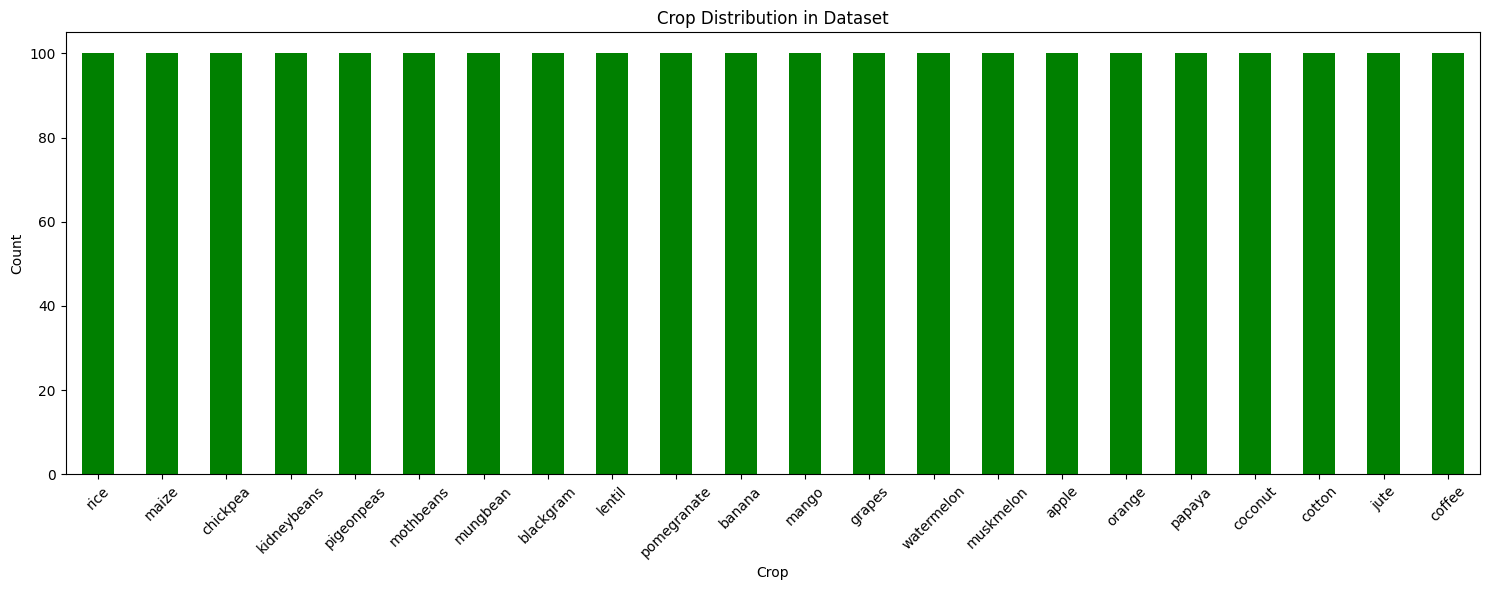

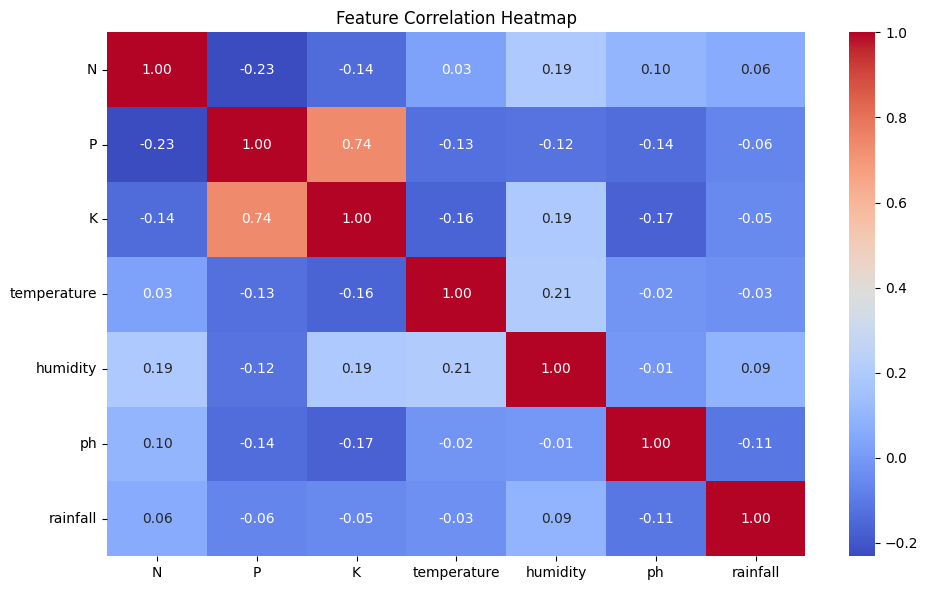

✅ Visualizations Done!


In [5]:
# Plot crop distribution
plt.figure(figsize=(15, 6))
crop_df['label'].value_counts().plot(kind='bar', color='green')
plt.title('Crop Distribution in Dataset')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crop_df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("✅ Visualizations Done!")

In [7]:
# Encode the label column
le = LabelEncoder()
crop_df['crop_encoded'] = le.fit_transform(crop_df['label'])

# Features and target
X = crop_df.drop(['label', 'crop_encoded'], axis=1)
y = crop_df['crop_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data Preprocessing Done!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Features: {X_train.columns.tolist()}")

✅ Data Preprocessing Done!
Training samples: 1760
Testing samples: 440
Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [ ]:
# Start MLflow experiment
mlflow.set_experiment("CropCareAI_ML_Pipeline")

# Train Random Forest with MLflow tracking
with mlflow.start_run(run_name="RandomForest_Crop_Recommendation"):
    
    # Model parameters
    n_estimators = 100
    max_depth = 10
    
    # Train model
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )
    rf_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Log parameters and metrics to MLflow
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_metric("accuracy", accuracy)
    
    # Log model
    mlflow.sklearn.log_model(rf_model, "random_forest_model")
    
    print(f"✅ Random Forest trained!")
    print(f"🎯 Accuracy: {accuracy * 100:.2f}%")

2026/04/23 16:34:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/23 16:34:19 INFO mlflow.store.db.utils: Updating database tables
2026/04/23 16:34:21 INFO mlflow.tracking.fluent: Experiment with name 'CropCareAI_ML_Pipeline' does not exist. Creating a new experiment.
2026/04/23 16:34:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 16:34:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
